Descargar todos lso archivos de datos desde 2020 hasta 2026 en https://www.gob.mx/salud/documentos/datos-abiertos-152127

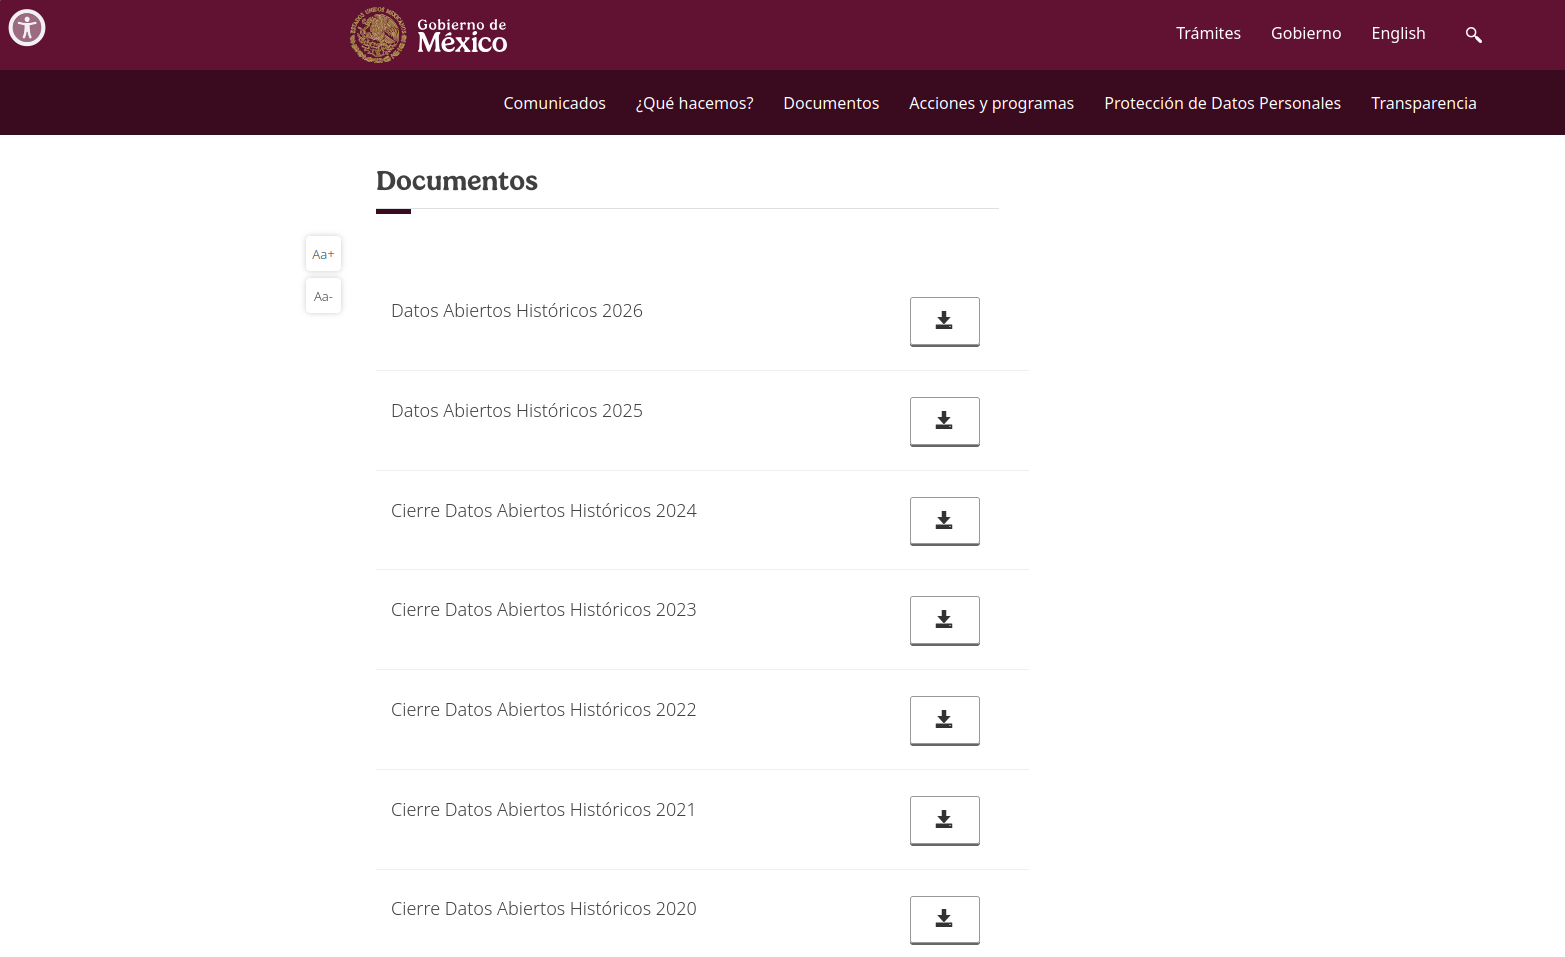

Guardarlos en la carpeta "data" y luego ejecutar el siguiente script para cargar los datos en la base de datos de mongo

## 1. Conexión a MongoDB

Antes de comenzar cualquier análisis, verificamos que la conexión con la base de datos **MongoDB** esté activa y funcional.

- Usamos `pymongo` como cliente de MongoDB desde Python.
- Las credenciales se cargan de forma segura desde el archivo `.env` usando `python-dotenv`.
- Ejecutamos un comando `ping` al servidor para confirmar que podemos comunicarnos con la base de datos sin errores.

> Si el ping responde con `{'ok': 1.0}`, la conexión es exitosa y podemos continuar con el proyecto.

In [ ]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient

# Cargar variables de entorno desde .env
load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")
DB_NAME = os.getenv("DB_NAME")

# Conectar al servidor de MongoDB
client = MongoClient(MONGO_URI)
db = client[DB_NAME]

# Ping para verificar la conexión
result = client.admin.command("ping")
print("Ping a MongoDB:", result)
print(f"Base de datos activa: {DB_NAME}")

## 2. Carga de datos raw a MongoDB

Se procesan los archivos ZIP del directorio `data/`, cada uno contiene un CSV con registros de COVID-19 de México.

**Estrategia de carga:**
- Cada año se almacena en su propia colección: `2020_raw`, `2021_raw`, … `2026_raw`.
- Los CSV se leen en **chunks** para no saturar la RAM.
- Se crea un índice único sobre `ID_REGISTRO` para detección automática de duplicados.
- Los registros se insertan con `ordered=False`, lo que permite continuar ante duplicados sin abortar el lote.
- Se procesan los años en orden cronológico: 2020 → 2026.

**Estadísticas reportadas por año:**
- Total de filas en el CSV
- Documentos insertados exitosamente
- Duplicados encontrados (ya existían en la colección)

Al final se muestra un resumen global con el total acumulado de todos los años.

In [2]:
import zipfile
import pandas as pd
from pymongo.errors import BulkWriteError

CHUNK_SIZE = 50_000
DATA_DIR = "data"
YEARS = range(2020, 2027)

ZIP_MAP = {
    2020: ("DATA_RAW_2020.zip", "COVID19MEXICO2020.csv"),
    2021: ("DATA_RAW_2021.zip", "COVID19MEXICO2021.csv"),
    2022: ("DATA_RAW_2022.zip", "COVID19MEXICO2022.csv"),
    2023: ("DATA_RAW_2023.zip", "COVID19MEXICO.csv"),
    2024: ("DATA_RAW_2024.zip", "COVID19MEXICO.csv"),
    2025: ("DATA_RAW_2025.zip", "COVID19MEXICO.csv"),
    2026: ("DATA_RAW_2026.zip", "COVID19MEXICO.csv"),
}

total_inserted_global = 0
total_duplicates_global = 0
total_rows_global = 0

summary_rows = []

for year in YEARS:
    zip_file, csv_file = ZIP_MAP[year]
    zip_path = f"{DATA_DIR}/{zip_file}"
    collection_name = f"{year}_raw"

    collection = db[collection_name]
    collection.create_index("ID_REGISTRO", unique=True)

    inserted_year = 0
    duplicates_year = 0
    rows_year = 0

    print(f"\n{'='*55}")
    print(f"  Procesando {year} → colección '{collection_name}'")
    print(f"{'='*55}")

    with zipfile.ZipFile(zip_path) as z:
        with z.open(csv_file) as f:
            reader = pd.read_csv(
                f,
                chunksize=CHUNK_SIZE,
                encoding="latin-1",
                low_memory=False,
            )
            for chunk_num, chunk in enumerate(reader, start=1):
                rows_year += len(chunk)
                docs = chunk.where(pd.notna(chunk), None).to_dict("records")

                try:
                    result = collection.insert_many(docs, ordered=False)
                    inserted_year += len(result.inserted_ids)
                except BulkWriteError as bwe:
                    inserted_year += bwe.details.get("nInserted", 0)
                    duplicates_year += len(bwe.details.get("writeErrors", []))

                if chunk_num % 10 == 0:
                    print(f"  · Chunk {chunk_num:>4} | filas acum.: {rows_year:>8,}")

    total_inserted_global += inserted_year
    total_duplicates_global += duplicates_year
    total_rows_global += rows_year

    summary_rows.append({
        "Año": year,
        "Filas CSV": rows_year,
        "Insertados": inserted_year,
        "Duplicados": duplicates_year,
    })

    print(f"\n  Resultado {year}:")
    print(f"    Filas en CSV  : {rows_year:>10,}")
    print(f"    Insertados    : {inserted_year:>10,}")
    print(f"    Duplicados    : {duplicates_year:>10,}")

print(f"\n{'='*55}")
print("  RESUMEN GLOBAL")
print(f"{'='*55}")

summary_df = pd.DataFrame(summary_rows).set_index("Año")
print(summary_df.to_string())

print(f"\n  Total filas CSV   : {total_rows_global:>12,}")
print(f"  Total insertados  : {total_inserted_global:>12,}")
print(f"  Total duplicados  : {total_duplicates_global:>12,}")
print(f"{'='*55}")


  Procesando 2020 → colección '2020_raw'
  · Chunk   10 | filas acum.:  500,000
  · Chunk   20 | filas acum.: 1,000,000
  · Chunk   30 | filas acum.: 1,500,000
  · Chunk   40 | filas acum.: 2,000,000
  · Chunk   50 | filas acum.: 2,500,000
  · Chunk   60 | filas acum.: 3,000,000
  · Chunk   70 | filas acum.: 3,500,000

  Resultado 2020:
    Filas en CSV  :  3,868,396
    Insertados    :  3,868,396
    Duplicados    :          0

  Procesando 2021 → colección '2021_raw'
  · Chunk   10 | filas acum.:  500,000
  · Chunk   20 | filas acum.: 1,000,000
  · Chunk   30 | filas acum.: 1,500,000
  · Chunk   40 | filas acum.: 2,000,000
  · Chunk   50 | filas acum.: 2,500,000
  · Chunk   60 | filas acum.: 3,000,000
  · Chunk   70 | filas acum.: 3,500,000
  · Chunk   80 | filas acum.: 4,000,000
  · Chunk   90 | filas acum.: 4,500,000
  · Chunk  100 | filas acum.: 5,000,000
  · Chunk  110 | filas acum.: 5,500,000
  · Chunk  120 | filas acum.: 6,000,000
  · Chunk  130 | filas acum.: 6,500,000
  · Ch

## 3. Verificación de conteos en MongoDB

Una vez cargados los datos, consultamos directamente cada colección en MongoDB para confirmar cuántos documentos quedaron almacenados por año y el total acumulado.

In [3]:
years = range(2020, 2027)
total = 0

print(f"{'Colección':<15} {'Documentos':>12}")
print("-" * 28)

for year in years:
    count = db[f"{year}_raw"].count_documents({})
    total += count
    print(f"{year}_raw{'':<8} {count:>12,}")

print("-" * 28)
print(f"{'TOTAL':<15} {total:>12,}")

Colección         Documentos
----------------------------
2020_raw            3,868,396
2021_raw            8,830,345
2022_raw            6,451,944
2023_raw            1,222,219
2024_raw              177,618
2025_raw              157,142
2026_raw              217,324
----------------------------
TOTAL             20,924,988


## 4. Colección unificada — `covid_unified`

### Cambio oficial de esquema (8 de julio de 2024)

A partir del paquete publicado el **8 de julio de 2024**, la Dirección General de Epidemiología realizó los siguientes cambios en las variables:

| Acción | Variable anterior | Variable nueva |
|---|---|---|
| Eliminada / reemplazada | `RESULTADO_LAB` | `RESULTADO_PCR` + `RESULTADO_PCR_COINFECCION` |
| Renombrada | `CLASIFICACION_FINAL` | `CLASIFICACION_FINAL_COVID` |
| Agregada | — | `CLASIFICACION_FINAL_FLU` |

El motivo del cambio es que el sistema ya no registra exclusivamente casos de COVID-19, sino todos los virus respiratorios vigilados por el **SISVER** (Sistema de Vigilancia Epidemiológica de las Enfermedades Respiratorias Virales).

Verificando las colecciones raw, el corte queda así:
- **Esquema viejo** → `2020_raw`, `2021_raw`, `2022_raw`, `2023_raw`
- **Esquema nuevo** → `2024_raw`, `2025_raw`, `2026_raw`

---

### Estrategia de unificación

1. **Esquema destino:** se adopta el esquema nuevo (2024+) como esquema canónico de `covid_unified`.
2. **Normalización de registros 2020–2023:**
   - `RESULTADO_LAB` → se mapea a `RESULTADO_PCR`
   - `RESULTADO_PCR_COINFECCION` → se agrega con valor `None` (no existía)
   - `CLASIFICACION_FINAL` → se renombra a `CLASIFICACION_FINAL_COVID`
   - `CLASIFICACION_FINAL_FLU` → se agrega con valor `None` (no existía)
3. **Deduplicación global:** índice único sobre `ID_REGISTRO` en `covid_unified`. Al procesar de 2020 → 2026, si un ID ya existe, el registro más reciente se descarta (gana el primero visto).
4. **Eficiencia de memoria:** se itera sobre cada colección raw usando cursores de MongoDB con `batch_size=50000`, sin cargar todo en RAM.

In [4]:
from pymongo.errors import BulkWriteError

BATCH_SIZE = 50_000

# Colecciones que usan el esquema anterior al 8-jul-2024
OLD_SCHEMA_YEARS = {2020, 2021, 2022, 2023}

unified = db["covid_unified"]
unified.drop()
unified.create_index("ID_REGISTRO", unique=True)

def normalize(doc, year):
    """Mapea el esquema viejo al esquema canónico nuevo."""
    if year in OLD_SCHEMA_YEARS:
        doc["RESULTADO_PCR"] = doc.pop("RESULTADO_LAB", None)
        doc["RESULTADO_PCR_COINFECCION"] = None
        doc["CLASIFICACION_FINAL_COVID"] = doc.pop("CLASIFICACION_FINAL", None)
        doc["CLASIFICACION_FINAL_FLU"] = None
    return doc

total_inserted = 0
total_duplicates = 0
summary = []

for year in range(2020, 2027):
    col = db[f"{year}_raw"]
    inserted_year = 0
    duplicates_year = 0
    batch = []

    print(f"\n{'='*52}")
    print(f"  Unificando {year}_raw → covid_unified")
    print(f"{'='*52}")

    cursor = col.find({}, {"_id": 0}).batch_size(BATCH_SIZE)

    for doc in cursor:
        batch.append(normalize(doc, year))

        if len(batch) == BATCH_SIZE:
            try:
                res = unified.insert_many(batch, ordered=False)
                inserted_year += len(res.inserted_ids)
            except BulkWriteError as bwe:
                inserted_year += bwe.details.get("nInserted", 0)
                duplicates_year += len(bwe.details.get("writeErrors", []))
            batch = []

    if batch:
        try:
            res = unified.insert_many(batch, ordered=False)
            inserted_year += len(res.inserted_ids)
        except BulkWriteError as bwe:
            inserted_year += bwe.details.get("nInserted", 0)
            duplicates_year += len(bwe.details.get("writeErrors", []))

    total_inserted += inserted_year
    total_duplicates += duplicates_year
    summary.append({"Año": year, "Insertados": inserted_year, "Duplicados descartados": duplicates_year})

    print(f"  Insertados        : {inserted_year:>10,}")
    print(f"  Duplicados desc.  : {duplicates_year:>10,}")

print(f"\n{'='*52}")
print("  RESUMEN FINAL — covid_unified")
print(f"{'='*52}")
import pandas as pd
df = pd.DataFrame(summary).set_index("Año")
print(df.to_string())
print(f"\n  Total en covid_unified : {total_inserted:>10,}")
print(f"  Total duplicados desc. : {total_duplicates:>10,}")
print(f"{'='*52}")


  Unificando 2020_raw → covid_unified
  Insertados        :  3,868,396
  Duplicados desc.  :          0

  Unificando 2021_raw → covid_unified
  Insertados        :  8,830,344
  Duplicados desc.  :          1

  Unificando 2022_raw → covid_unified
  Insertados        :  6,451,941
  Duplicados desc.  :          3

  Unificando 2023_raw → covid_unified
  Insertados        :  1,222,219
  Duplicados desc.  :          0

  Unificando 2024_raw → covid_unified
  Insertados        :    177,618
  Duplicados desc.  :          0

  Unificando 2025_raw → covid_unified
  Insertados        :    157,142
  Duplicados desc.  :          0

  Unificando 2026_raw → covid_unified
  Insertados        :     60,406
  Duplicados desc.  :    156,918

  RESUMEN FINAL — covid_unified
      Insertados  Duplicados descartados
Año                                     
2020     3868396                       0
2021     8830344                       1
2022     6451941                       3
2023     1222219           

## 5. Colección Durango — `durango`

El análisis de caso de estudio se enfoca en el estado de **Durango** (clave `10` en el catálogo de entidades de la SSa).

Se consideran dos criterios de inclusión:
- `ENTIDAD_RES = 10` — el paciente **reside** en Durango
- `ENTIDAD_NAC = 10` — el paciente **nació** en Durango

Primero se verifica el conteo esperado sobre `covid_unified`, y después se materializa la colección `durango` con esos registros.

In [5]:
DURANGO_FILTER = {"$or": [{"ENTIDAD_RES": 10}, {"ENTIDAD_NAC": 10}]}

# Verificación de conteo antes de crear la colección
conteo_durango = db["covid_unified"].count_documents(DURANGO_FILTER)
print(f"Registros Durango (ENTIDAD_RES=10 OR ENTIDAD_NAC=10): {conteo_durango:,}")

Registros Durango (ENTIDAD_RES=10 OR ENTIDAD_NAC=10): 250,008


In [6]:
BATCH_SIZE = 50_000

durango_col = db["durango"]
durango_col.drop()
durango_col.create_index("ID_REGISTRO", unique=True)

inserted = 0
batch = []

cursor = db["covid_unified"].find(DURANGO_FILTER, {"_id": 0}).batch_size(BATCH_SIZE)

for doc in cursor:
    batch.append(doc)
    if len(batch) == BATCH_SIZE:
        res = durango_col.insert_many(batch, ordered=False)
        inserted += len(res.inserted_ids)
        batch = []

if batch:
    res = durango_col.insert_many(batch, ordered=False)
    inserted += len(res.inserted_ids)

print(f"Documentos insertados en 'durango': {inserted:,}")
print(f"Verificación final               : {durango_col.count_documents({}):,}")

Documentos insertados en 'durango': 250,008
Verificación final               : 250,008


## 6. Estadística descriptiva — EDAD e HIPERTENSIÓN (Durango)

Se trabaja sobre la colección `durango` para calcular estadísticas de las variables numéricas **EDAD** e **HIPERTENSIÓN**.

### Verificación de tipos de dato

Antes de operar, se verificó que ambas variables están almacenadas como `int` en MongoDB, por lo que no se requiere conversión de tipo.

### Codificación de HIPERTENSIÓN

El catálogo oficial de la SSa define los valores de HIPERTENSIÓN así:

| Valor | Significado |
|---|---|
| `1` | Sí |
| `2` | No |
| `97` | No aplica |
| `98` | Se ignora |
| `99` | No especificado |

En la colección `durango` únicamente aparecen los valores `1`, `2` y `98`. Para el cálculo de covarianza se **recodifica a binario** (`1` → `1`, `2` → `0`); cualquier valor fuera de ese rango (97, 98, 99) queda como `NaN` y se excluye automáticamente del análisis.

### Estadísticas calculadas

- **EDAD:** Máximo, Mínimo, Promedio, Varianza, Percentiles (25, 50, 75, 90, 95) y Cuartiles
- **Covarianza:** EDAD vs HIPERTENSIÓN (binario, excluyendo valores no válidos)

In [10]:
import pandas as pd
import numpy as np

# Cargar solo las columnas necesarias desde MongoDB
cursor = db["durango"].find({}, {"_id": 0, "EDAD": 1, "HIPERTENSION": 1})
df = pd.DataFrame(list(cursor))

# Recodificar HIPERTENSION: 1→1 (sí), 2→0 (no), 98→NaN
df["HIPERTENSION_BIN"] = df["HIPERTENSION"].map({1: 1, 2: 0})  # 98 queda como NaN

print(f"Total registros cargados     : {len(df):,}")
print(f"Registros con HIPERTENSION=98: {(df['HIPERTENSION'] == 98).sum():,} (excluidos del análisis)")
print(f"Registros válidos p/ cov.    : {df['HIPERTENSION_BIN'].notna().sum():,}")
print(f"\nTipos de dato:")
print(df.dtypes)

Total registros cargados     : 250,008
Registros con HIPERTENSION=98: 2,928 (excluidos del análisis)
Registros válidos p/ cov.    : 247,080

Tipos de dato:
EDAD                  int64
HIPERTENSION          int64
HIPERTENSION_BIN    float64
dtype: object


In [11]:
edad = df["EDAD"]
df_valido = df.dropna(subset=["HIPERTENSION_BIN"])

# ── Estadísticas de EDAD ──────────────────────────────────────
print("=" * 45)
print("  ESTADÍSTICAS — EDAD")
print("=" * 45)
print(f"  Mínimo      : {edad.min()}")
print(f"  Máximo      : {edad.max()}")
print(f"  Promedio    : {edad.mean():.4f}")
print(f"  Varianza    : {edad.var():.4f}")
print()

percentiles = [25, 50, 75, 90, 95]
print("  Percentiles:")
for p in percentiles:
    print(f"    P{p:<2}       : {np.percentile(edad, p):.2f}")

print()
q1, q2, q3 = edad.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
print("  Cuartiles:")
print(f"    Q1 (25%)  : {q1:.2f}")
print(f"    Q2 (50%)  : {q2:.2f}")
print(f"    Q3 (75%)  : {q3:.2f}")
print(f"    IQR       : {iqr:.2f}")

# ── Covarianza EDAD vs HIPERTENSION ──────────────────────────
print()
print("=" * 45)
print("  COVARIANZA — EDAD vs HIPERTENSIÓN")
print("=" * 45)
cov_matrix = df_valido[["EDAD", "HIPERTENSION_BIN"]].cov()
cov_val = cov_matrix.loc["EDAD", "HIPERTENSION_BIN"]
print(f"  Cov(EDAD, HIPERTENSIÓN) : {cov_val:.4f}")
print()
print("  Matriz de covarianza completa:")
print(cov_matrix.to_string())

  ESTADÍSTICAS — EDAD
  Mínimo      : 0
  Máximo      : 122
  Promedio    : 39.6181
  Varianza    : 322.3674

  Percentiles:
    P25       : 27.00
    P50       : 37.00
    P75       : 51.00
    P90       : 65.00
    P95       : 73.00

  Cuartiles:
    Q1 (25%)  : 27.00
    Q2 (50%)  : 37.00
    Q3 (75%)  : 51.00
    IQR       : 24.00

  COVARIANZA — EDAD vs HIPERTENSIÓN
  Cov(EDAD, HIPERTENSIÓN) : 2.4646

  Matriz de covarianza completa:
                        EDAD  HIPERTENSION_BIN
EDAD              321.808218          2.464626
HIPERTENSION_BIN    2.464626          0.109870


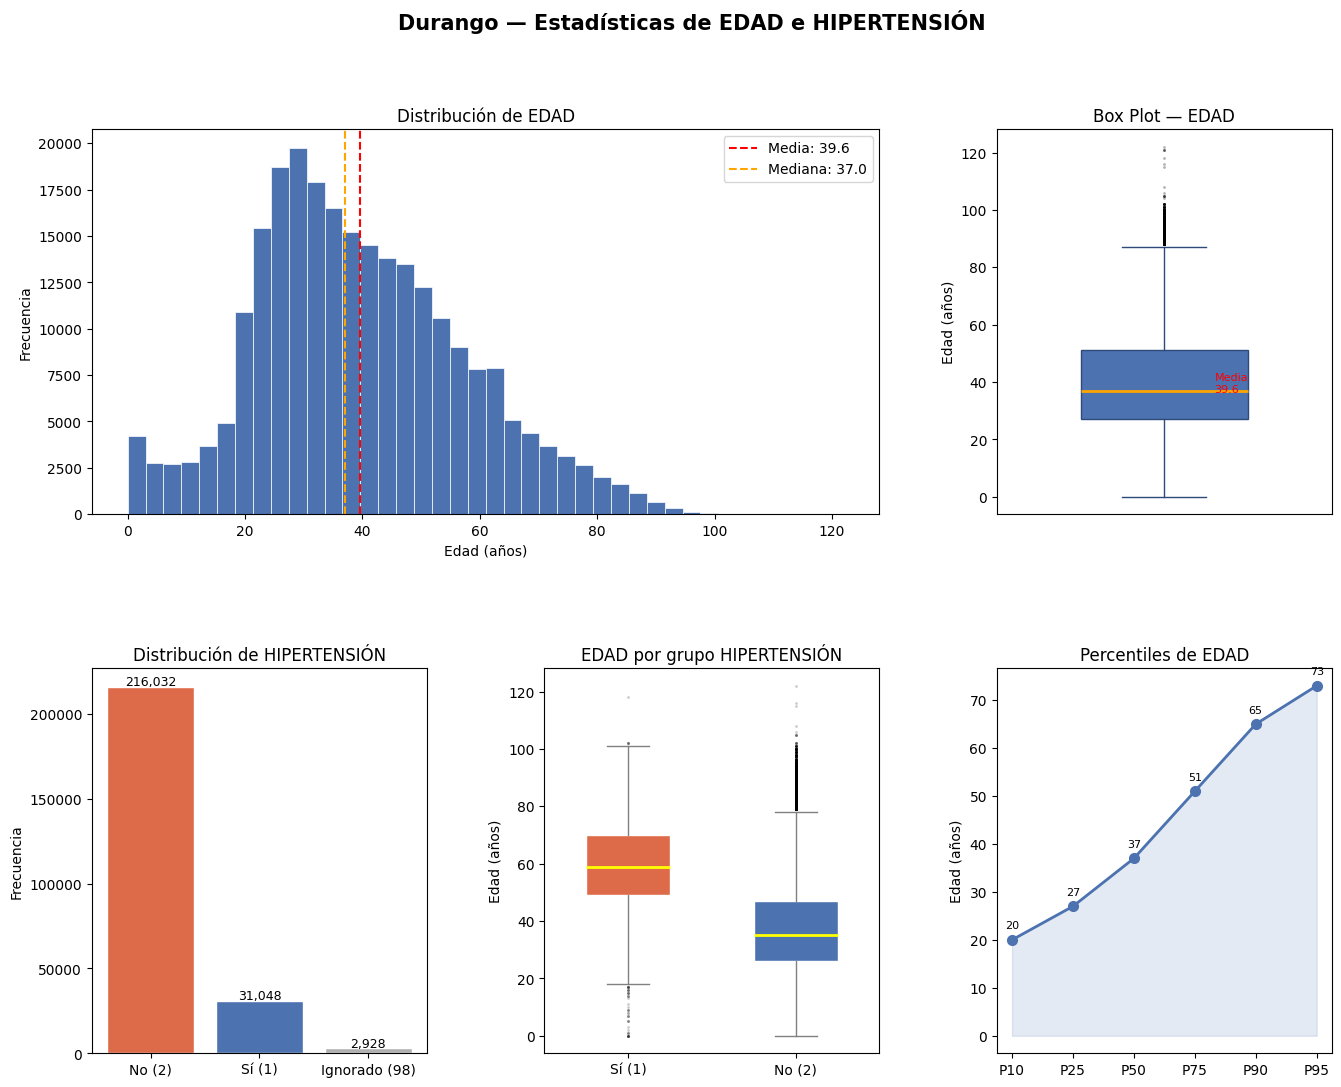

Figura guardada: estadisticas_durango.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Durango — Estadísticas de EDAD e HIPERTENSIÓN", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Histograma de EDAD ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(edad, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax1.axvline(edad.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Media: {edad.mean():.1f}")
ax1.axvline(q2, color="orange", linestyle="--", linewidth=1.5, label=f"Mediana: {q2:.1f}")
ax1.set_title("Distribución de EDAD")
ax1.set_xlabel("Edad (años)")
ax1.set_ylabel("Frecuencia")
ax1.legend()

# ── 2. Box plot de EDAD ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
bp = ax2.boxplot(edad, patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor="#4C72B0", color="#2d4a7a"),
                 medianprops=dict(color="orange", linewidth=2),
                 whiskerprops=dict(color="#2d4a7a"),
                 capprops=dict(color="#2d4a7a"),
                 flierprops=dict(marker=".", color="gray", alpha=0.3, markersize=2))
ax2.set_title("Box Plot — EDAD")
ax2.set_ylabel("Edad (años)")
ax2.set_xticks([])
ax2.text(1.15, edad.mean(), f"Media\n{edad.mean():.1f}", va="center", fontsize=8, color="red")

# ── 3. Barras HIPERTENSIÓN ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
hiper_counts = df["HIPERTENSION"].map({1: "Sí (1)", 2: "No (2)", 98: "Ignorado (98)"}).value_counts()
colors_bar = ["#dd6b4a", "#4C72B0", "#b0b0b0"]
bars = ax3.bar(hiper_counts.index, hiper_counts.values, color=colors_bar, edgecolor="white")
ax3.set_title("Distribución de HIPERTENSIÓN")
ax3.set_ylabel("Frecuencia")
for bar, val in zip(bars, hiper_counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", fontsize=9)

# ── 4. Box plot EDAD por grupo HIPERTENSIÓN ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
grupo_si  = df_valido[df_valido["HIPERTENSION_BIN"] == 1]["EDAD"]
grupo_no  = df_valido[df_valido["HIPERTENSION_BIN"] == 0]["EDAD"]
bp2 = ax4.boxplot([grupo_si, grupo_no], patch_artist=True, widths=0.5,
                  boxprops=dict(color="white"),
                  medianprops=dict(color="yellow", linewidth=2),
                  whiskerprops=dict(color="gray"),
                  capprops=dict(color="gray"),
                  flierprops=dict(marker=".", color="gray", alpha=0.2, markersize=2))
bp2["boxes"][0].set_facecolor("#dd6b4a")
bp2["boxes"][1].set_facecolor("#4C72B0")
ax4.set_title("EDAD por grupo HIPERTENSIÓN")
ax4.set_xticklabels(["Sí (1)", "No (2)"])
ax4.set_ylabel("Edad (años)")

# ── 5. Percentiles de EDAD ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ps = [10, 25, 50, 75, 90, 95]
pvals = [np.percentile(edad, p) for p in ps]
ax5.plot([f"P{p}" for p in ps], pvals, marker="o", color="#4C72B0", linewidth=2, markersize=7)
ax5.fill_between(range(len(ps)), pvals, alpha=0.15, color="#4C72B0")
ax5.set_title("Percentiles de EDAD")
ax5.set_ylabel("Edad (años)")
ax5.set_xticks(range(len(ps)))
ax5.set_xticklabels([f"P{p}" for p in ps])
for i, (p, v) in enumerate(zip(ps, pvals)):
    ax5.annotate(f"{v:.0f}", (i, v), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8)

plt.savefig("estadisticas_durango.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: estadisticas_durango.png")

## 7. Integración de datos — ENTIDAD_UM = 10

Este paso simula un escenario real de **integración de datos** desde una fuente adicional.

La colección `durango` se construyó originalmente con dos criterios:
- `ENTIDAD_RES = 10` — paciente reside en Durango
- `ENTIDAD_NAC = 10` — paciente nació en Durango

Ahora se integra una tercera fuente: registros donde la **unidad médica** que atendió al paciente pertenece a Durango (`ENTIDAD_UM = 10`), independientemente de dónde resida o haya nacido el paciente.

### Manejo de duplicados en la integración

Para evitar insertar registros que ya existen en `durango`, la consulta a `covid_unified` aplica una proyección exclusiva:

```
ENTIDAD_UM = 10  AND  ENTIDAD_RES ≠ 10  AND  ENTIDAD_NAC ≠ 10
```

Esto garantiza que los documentos a insertar son **disjuntos** con los ya existentes en la colección, por lo que el conteo de la consulta debe coincidir exactamente con el número de documentos insertados.

In [13]:
from pymongo.errors import BulkWriteError

UM_FILTER = {
    "ENTIDAD_UM": 10,
    "ENTIDAD_RES": {"$ne": 10},
    "ENTIDAD_NAC": {"$ne": 10},
}

# Conteo previo — debe coincidir con los insertados
conteo_um = db["covid_unified"].count_documents(UM_FILTER)
print(f"Registros nuevos a integrar (ENTIDAD_UM=10, no RES/NAC): {conteo_um:,}")

# Inserción en durango
BATCH_SIZE = 50_000
inserted_um = 0
duplicates_um = 0
batch = []

cursor = db["covid_unified"].find(UM_FILTER, {"_id": 0}).batch_size(BATCH_SIZE)

for doc in cursor:
    batch.append(doc)
    if len(batch) == BATCH_SIZE:
        try:
            res = durango_col.insert_many(batch, ordered=False)
            inserted_um += len(res.inserted_ids)
        except BulkWriteError as bwe:
            inserted_um += bwe.details.get("nInserted", 0)
            duplicates_um += len(bwe.details.get("writeErrors", []))
        batch = []

if batch:
    try:
        res = durango_col.insert_many(batch, ordered=False)
        inserted_um += len(res.inserted_ids)
    except BulkWriteError as bwe:
        inserted_um += bwe.details.get("nInserted", 0)
        duplicates_um += len(bwe.details.get("writeErrors", []))

total_durango = durango_col.count_documents({})

print(f"\nRegistros en consulta : {conteo_um:,}")
print(f"Insertados            : {inserted_um:,}")
print(f"Duplicados rechazados : {duplicates_um:,}")
print(f"{'✓ Coinciden' if conteo_um == inserted_um else '✗ Discrepancia'}")
print(f"\nTotal en colección durango: {total_durango:,}")

Registros nuevos a integrar (ENTIDAD_UM=10, no RES/NAC): 2,983

Registros en consulta : 2,983
Insertados            : 2,983
Duplicados rechazados : 0
✓ Coinciden

Total en colección durango: 252,991


## 8. Estadística descriptiva — EDAD e HIPERTENSIÓN (Durango actualizado)

Se repite el análisis estadístico del paso anterior, ahora sobre la colección `durango` **tras la integración de ENTIDAD_UM = 10** (253,991 registros vs 250,008 originales).

Al final se comparan ambos resultados para observar el impacto que tuvo la integración de los 2,983 registros adicionales sobre las estadísticas.

In [16]:
# Cargar datos actualizados desde durango
cursor2 = db["durango"].find({}, {"_id": 0, "EDAD": 1, "HIPERTENSION": 1})
df2 = pd.DataFrame(list(cursor2))

df2["HIPERTENSION_BIN"] = df2["HIPERTENSION"].map({1: 1, 2: 0})

print(f"Total registros cargados     : {len(df2):,}")
print(f"Registros con HIPERTENSION=98: {(df2['HIPERTENSION'] == 98).sum():,} (excluidos del análisis)")
print(f"Registros válidos p/ cov.    : {df2['HIPERTENSION_BIN'].notna().sum():,}")

Total registros cargados     : 252,991
Registros con HIPERTENSION=98: 2,957 (excluidos del análisis)
Registros válidos p/ cov.    : 250,034


In [17]:
edad2 = df2["EDAD"]
df2_valido = df2.dropna(subset=["HIPERTENSION_BIN"])

print("=" * 45)
print("  ESTADÍSTICAS — EDAD (actualizado)")
print("=" * 45)
print(f"  Mínimo      : {edad2.min()}")
print(f"  Máximo      : {edad2.max()}")
print(f"  Promedio    : {edad2.mean():.4f}")
print(f"  Varianza    : {edad2.var():.4f}")
print()

percentiles2 = [25, 50, 75, 90, 95]
print("  Percentiles:")
for p in percentiles2:
    print(f"    P{p:<2}       : {np.percentile(edad2, p):.2f}")

print()
q1_2, q2_2, q3_2 = edad2.quantile([0.25, 0.50, 0.75])
iqr2 = q3_2 - q1_2
print("  Cuartiles:")
print(f"    Q1 (25%)  : {q1_2:.2f}")
print(f"    Q2 (50%)  : {q2_2:.2f}")
print(f"    Q3 (75%)  : {q3_2:.2f}")
print(f"    IQR       : {iqr2:.2f}")

print()
print("=" * 45)
print("  COVARIANZA — EDAD vs HIPERTENSIÓN")
print("=" * 45)
cov_matrix2 = df2_valido[["EDAD", "HIPERTENSION_BIN"]].cov()
cov_val2 = cov_matrix2.loc["EDAD", "HIPERTENSION_BIN"]
print(f"  Cov(EDAD, HIPERTENSIÓN) : {cov_val2:.4f}")
print()
print("  Matriz de covarianza completa:")
print(cov_matrix2.to_string())

  ESTADÍSTICAS — EDAD (actualizado)
  Mínimo      : 0
  Máximo      : 122
  Promedio    : 39.6203
  Varianza    : 321.8964

  Percentiles:
    P25       : 27.00
    P50       : 37.00
    P75       : 51.00
    P90       : 65.00
    P95       : 73.00

  Cuartiles:
    Q1 (25%)  : 27.00
    Q2 (50%)  : 37.00
    Q3 (75%)  : 51.00
    IQR       : 24.00

  COVARIANZA — EDAD vs HIPERTENSIÓN
  Cov(EDAD, HIPERTENSIÓN) : 2.4584

  Matriz de covarianza completa:
                        EDAD  HIPERTENSION_BIN
EDAD              321.358556          2.458432
HIPERTENSION_BIN    2.458432          0.109722


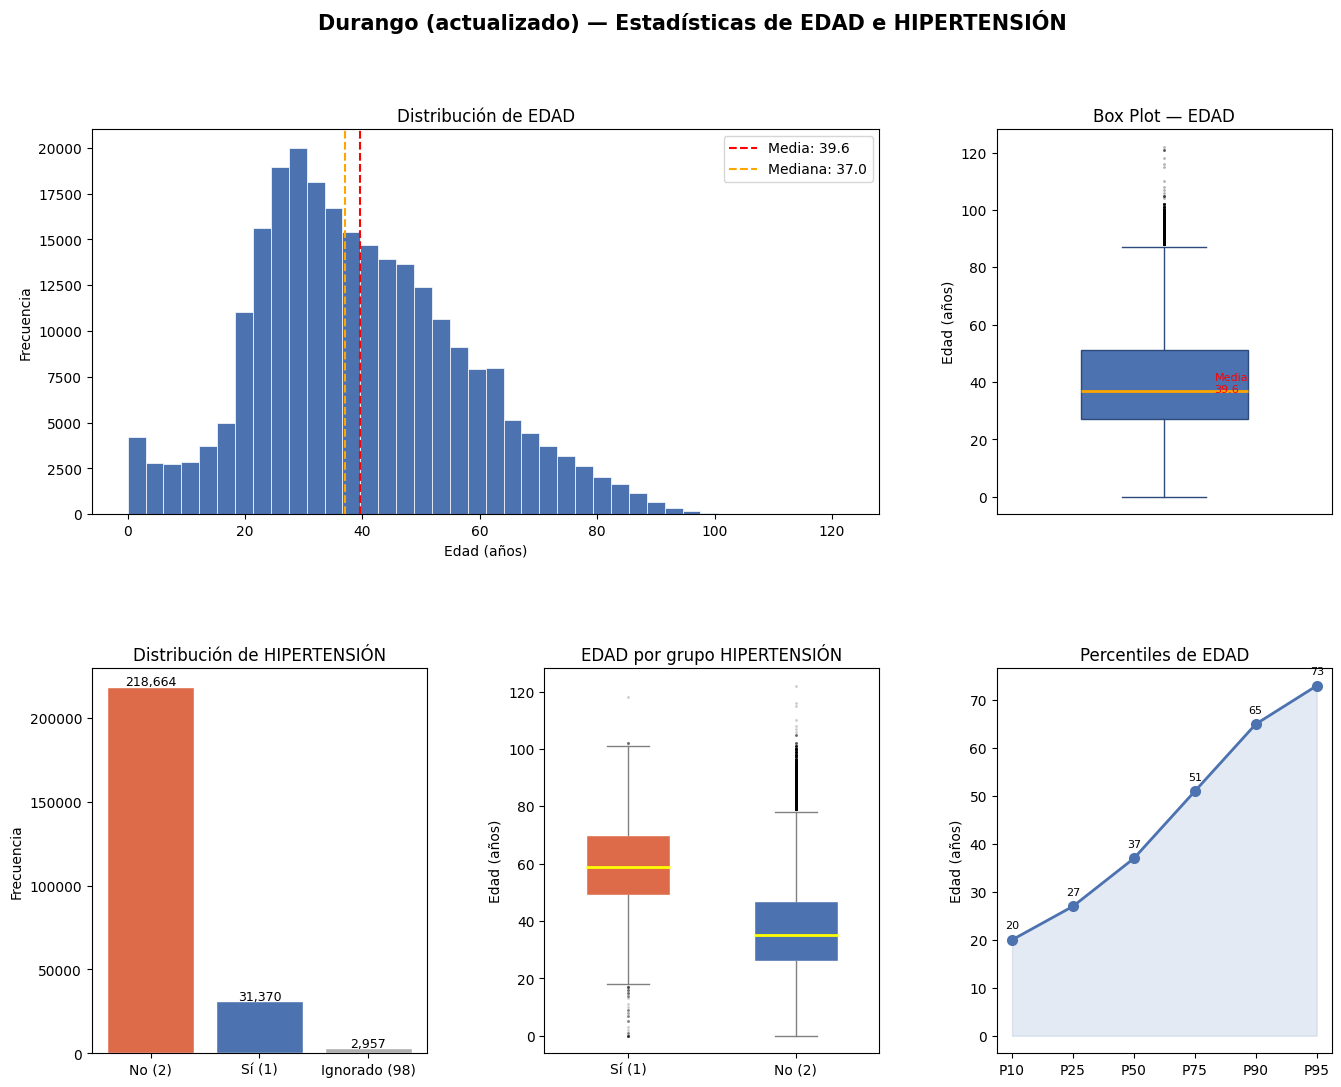

Figura guardada: estadisticas_durango_actualizado.png


In [18]:
fig2 = plt.figure(figsize=(16, 12))
fig2.suptitle("Durango (actualizado) — Estadísticas de EDAD e HIPERTENSIÓN", fontsize=15, fontweight="bold", y=0.98)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.4, wspace=0.35)

ax1 = fig2.add_subplot(gs2[0, :2])
ax1.hist(edad2, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax1.axvline(edad2.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Media: {edad2.mean():.1f}")
ax1.axvline(q2_2, color="orange", linestyle="--", linewidth=1.5, label=f"Mediana: {q2_2:.1f}")
ax1.set_title("Distribución de EDAD")
ax1.set_xlabel("Edad (años)")
ax1.set_ylabel("Frecuencia")
ax1.legend()

ax2 = fig2.add_subplot(gs2[0, 2])
ax2.boxplot(edad2, patch_artist=True, widths=0.5,
            boxprops=dict(facecolor="#4C72B0", color="#2d4a7a"),
            medianprops=dict(color="orange", linewidth=2),
            whiskerprops=dict(color="#2d4a7a"),
            capprops=dict(color="#2d4a7a"),
            flierprops=dict(marker=".", color="gray", alpha=0.3, markersize=2))
ax2.set_title("Box Plot — EDAD")
ax2.set_ylabel("Edad (años)")
ax2.set_xticks([])
ax2.text(1.15, edad2.mean(), f"Media\n{edad2.mean():.1f}", va="center", fontsize=8, color="red")

ax3 = fig2.add_subplot(gs2[1, 0])
hiper_counts2 = df2["HIPERTENSION"].map({1: "Sí (1)", 2: "No (2)", 98: "Ignorado (98)"}).value_counts()
bars2 = ax3.bar(hiper_counts2.index, hiper_counts2.values, color=["#dd6b4a", "#4C72B0", "#b0b0b0"], edgecolor="white")
ax3.set_title("Distribución de HIPERTENSIÓN")
ax3.set_ylabel("Frecuencia")
for bar, val in zip(bars2, hiper_counts2.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500, f"{val:,}", ha="center", fontsize=9)

ax4 = fig2.add_subplot(gs2[1, 1])
grupo_si2 = df2_valido[df2_valido["HIPERTENSION_BIN"] == 1]["EDAD"]
grupo_no2 = df2_valido[df2_valido["HIPERTENSION_BIN"] == 0]["EDAD"]
bp2 = ax4.boxplot([grupo_si2, grupo_no2], patch_artist=True, widths=0.5,
                  boxprops=dict(color="white"),
                  medianprops=dict(color="yellow", linewidth=2),
                  whiskerprops=dict(color="gray"), capprops=dict(color="gray"),
                  flierprops=dict(marker=".", color="gray", alpha=0.2, markersize=2))
bp2["boxes"][0].set_facecolor("#dd6b4a")
bp2["boxes"][1].set_facecolor("#4C72B0")
ax4.set_title("EDAD por grupo HIPERTENSIÓN")
ax4.set_xticklabels(["Sí (1)", "No (2)"])
ax4.set_ylabel("Edad (años)")

ax5 = fig2.add_subplot(gs2[1, 2])
ps2 = [10, 25, 50, 75, 90, 95]
pvals2 = [np.percentile(edad2, p) for p in ps2]
ax5.plot([f"P{p}" for p in ps2], pvals2, marker="o", color="#4C72B0", linewidth=2, markersize=7)
ax5.fill_between(range(len(ps2)), pvals2, alpha=0.15, color="#4C72B0")
ax5.set_title("Percentiles de EDAD")
ax5.set_ylabel("Edad (años)")
ax5.set_xticks(range(len(ps2)))
ax5.set_xticklabels([f"P{p}" for p in ps2])
for i, (p, v) in enumerate(zip(ps2, pvals2)):
    ax5.annotate(f"{v:.0f}", (i, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.savefig("estadisticas_durango_actualizado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: estadisticas_durango_actualizado.png")

In [19]:
# ── Comparativa antes vs después de la integración ───────────────────────────
stats_antes = {
    "Registros":  len(df),
    "Mínimo":     edad.min(),
    "Máximo":     edad.max(),
    "Promedio":   round(edad.mean(), 4),
    "Varianza":   round(edad.var(), 4),
    "Q1":         round(q1, 2),
    "Q2 (mediana)": round(q2, 2),
    "Q3":         round(q3, 2),
    "IQR":        round(iqr, 2),
    "P90":        round(np.percentile(edad, 90), 2),
    "P95":        round(np.percentile(edad, 95), 2),
    "Cov(EDAD, HIPERT.)": round(cov_val, 4),
}

stats_despues = {
    "Registros":  len(df2),
    "Mínimo":     edad2.min(),
    "Máximo":     edad2.max(),
    "Promedio":   round(edad2.mean(), 4),
    "Varianza":   round(edad2.var(), 4),
    "Q1":         round(q1_2, 2),
    "Q2 (mediana)": round(q2_2, 2),
    "Q3":         round(q3_2, 2),
    "IQR":        round(iqr2, 2),
    "P90":        round(np.percentile(edad2, 90), 2),
    "P95":        round(np.percentile(edad2, 95), 2),
    "Cov(EDAD, HIPERT.)": round(cov_val2, 4),
}

comp = pd.DataFrame({"Antes (250,008)": stats_antes, "Después (253,991)": stats_despues})
comp["Δ Diferencia"] = (comp["Después (253,991)"] - comp["Antes (250,008)"]).round(4)

print("=" * 65)
print("  COMPARATIVA — Antes vs Después de integración ENTIDAD_UM=10")
print("=" * 65)
print(comp.to_string())
print("=" * 65)

  COMPARATIVA — Antes vs Después de integración ENTIDAD_UM=10
                    Antes (250,008)  Después (253,991)  Δ Diferencia
Registros               250008.0000        252991.0000     2983.0000
Mínimo                       0.0000             0.0000        0.0000
Máximo                     122.0000           122.0000        0.0000
Promedio                    39.6181            39.6203        0.0022
Varianza                   322.3674           321.8964       -0.4710
Q1                          27.0000            27.0000        0.0000
Q2 (mediana)                37.0000            37.0000        0.0000
Q3                          51.0000            51.0000        0.0000
IQR                         24.0000            24.0000        0.0000
P90                         65.0000            65.0000        0.0000
P95                         73.0000            73.0000        0.0000
Cov(EDAD, HIPERT.)           2.4646             2.4584       -0.0062


## 9. Enriquecimiento de datos — Campos de días calculados

Se crean tres nuevos campos numéricos en la colección `durango` derivados de las fechas existentes:

| Campo nuevo | Fórmula | Descripción |
|---|---|---|
| `DIAS_SINTOMAS` | `FECHA_INGRESO − FECHA_SINTOMAS` | Días desde primeros síntomas hasta ingreso hospitalario |
| `DIAS_ATENCION` | `FECHA_DEF − FECHA_INGRESO` | Días de atención médica hasta defunción |
| `DIAS_ENFERMO` | `FECHA_DEF − FECHA_SINTOMAS` | Días totales de enfermedad hasta defunción |

### Consideraciones de limpieza

- Las fechas vienen como `string` en formato `YYYY-MM-DD` y se convierten a `datetime` para operar.
- `FECHA_DEF = '9999-99-99'` indica que el paciente **no falleció** — se trata como `None`.
- `DIAS_ATENCION` y `DIAS_ENFERMO` quedan en `None` para pacientes sin defunción registrada.
- `FECHA_INGRESO` y `FECHA_SINTOMAS` no contienen valores inválidos, por lo que `DIAS_SINTOMAS` se puede calcular para todos los registros.
- Los nuevos campos se agregan directamente a los documentos existentes en `durango` mediante `bulk_write`.

In [21]:
import pandas as pd

# Muestra representativa: 3 sin defunción y 3 con defunción
campos = {"_id": 0, "ID_REGISTRO": 1, "FECHA_INGRESO": 1, "FECHA_SINTOMAS": 1, "FECHA_DEF": 1}

sin_def = list(db["durango"].find({"FECHA_DEF": "9999-99-99"}, campos).limit(3))
con_def = list(db["durango"].find({"FECHA_DEF": {"$ne": "9999-99-99"}}, campos).limit(3))

muestra = pd.DataFrame(sin_def + con_def)
muestra["tiene_defuncion"] = muestra["FECHA_DEF"] != "9999-99-99"
print(muestra.to_string(index=False))

ID_REGISTRO FECHA_INGRESO FECHA_SINTOMAS  FECHA_DEF  tiene_defuncion
     z5ba5b    2020-07-31     2020-07-28 9999-99-99            False
     z4887b    2020-08-07     2020-08-05 9999-99-99            False
     z51d3b    2020-05-06     2020-05-05 9999-99-99            False
     1d34f6    2020-01-08     2020-01-04 2020-01-08             True
     171320    2020-01-16     2020-01-11 2020-01-17             True
     1e371e    2020-02-03     2020-01-31 2020-02-06             True


In [22]:
from datetime import datetime
from pymongo import UpdateOne

BATCH_SIZE = 10_000

def parse_fecha(s):
    """Convierte string YYYY-MM-DD a datetime. Retorna None si es 9999-99-99."""
    if s == "9999-99-99" or s is None:
        return None
    return datetime.strptime(s, "%Y-%m-%d")

def dias_entre(a, b):
    """Diferencia en días entre dos datetime. Retorna None si alguno es None."""
    if a is None or b is None:
        return None
    return (a - b).days

actualizados = 0
operaciones = []

campos_fecha = {"_id": 1, "FECHA_INGRESO": 1, "FECHA_SINTOMAS": 1, "FECHA_DEF": 1}
cursor = db["durango"].find({}, campos_fecha).batch_size(BATCH_SIZE)

for doc in cursor:
    fi  = parse_fecha(doc["FECHA_INGRESO"])
    fs  = parse_fecha(doc["FECHA_SINTOMAS"])
    fd  = parse_fecha(doc["FECHA_DEF"])

    operaciones.append(UpdateOne(
        {"_id": doc["_id"]},
        {"$set": {
            "DIAS_SINTOMAS": dias_entre(fi, fs),   # ingreso - síntomas
            "DIAS_ATENCION": dias_entre(fd, fi),   # defunción - ingreso
            "DIAS_ENFERMO":  dias_entre(fd, fs),   # defunción - síntomas
        }}
    ))

    if len(operaciones) == BATCH_SIZE:
        res = db["durango"].bulk_write(operaciones, ordered=False)
        actualizados += res.modified_count
        operaciones = []

if operaciones:
    res = db["durango"].bulk_write(operaciones, ordered=False)
    actualizados += res.modified_count

print(f"Documentos actualizados : {actualizados:,}")

# Muestra de resultados
campos_res = {"_id": 0, "ID_REGISTRO": 1, "FECHA_INGRESO": 1, "FECHA_SINTOMAS": 1,
              "FECHA_DEF": 1, "DIAS_SINTOMAS": 1, "DIAS_ATENCION": 1, "DIAS_ENFERMO": 1}

print("\n── Sin defunción (DIAS_ATENCION y DIAS_ENFERMO = None) ──")
for doc in db["durango"].find({"FECHA_DEF": "9999-99-99"}, campos_res).limit(3):
    print(doc)

print("\n── Con defunción ──")
for doc in db["durango"].find({"FECHA_DEF": {"$ne": "9999-99-99"}}, campos_res).limit(3):
    print(doc)

Documentos actualizados : 252,991

── Sin defunción (DIAS_ATENCION y DIAS_ENFERMO = None) ──
{'ID_REGISTRO': 'z5ba5b', 'FECHA_INGRESO': '2020-07-31', 'FECHA_SINTOMAS': '2020-07-28', 'FECHA_DEF': '9999-99-99', 'DIAS_ATENCION': None, 'DIAS_ENFERMO': None, 'DIAS_SINTOMAS': 3}
{'ID_REGISTRO': 'z4887b', 'FECHA_INGRESO': '2020-08-07', 'FECHA_SINTOMAS': '2020-08-05', 'FECHA_DEF': '9999-99-99', 'DIAS_ATENCION': None, 'DIAS_ENFERMO': None, 'DIAS_SINTOMAS': 2}
{'ID_REGISTRO': 'z51d3b', 'FECHA_INGRESO': '2020-05-06', 'FECHA_SINTOMAS': '2020-05-05', 'FECHA_DEF': '9999-99-99', 'DIAS_ATENCION': None, 'DIAS_ENFERMO': None, 'DIAS_SINTOMAS': 1}

── Con defunción ──
{'ID_REGISTRO': '1d34f6', 'FECHA_INGRESO': '2020-01-08', 'FECHA_SINTOMAS': '2020-01-04', 'FECHA_DEF': '2020-01-08', 'DIAS_ATENCION': 0, 'DIAS_ENFERMO': 4, 'DIAS_SINTOMAS': 4}
{'ID_REGISTRO': '171320', 'FECHA_INGRESO': '2020-01-16', 'FECHA_SINTOMAS': '2020-01-11', 'FECHA_DEF': '2020-01-17', 'DIAS_ATENCION': 1, 'DIAS_ENFERMO': 6, 'DIAS_SINTOMA

## 10. Defunciones por residencia en Durango

Se filtra sobre la colección `durango` los registros donde el paciente **reside en Durango** (`ENTIDAD_RES = 10`) y cuenta con una **fecha de defunción válida** (es decir, `FECHA_DEF ≠ '9999-99-99'`).

In [23]:
defunciones_res10 = db["durango"].count_documents({
    "ENTIDAD_RES": 10,
    "FECHA_DEF": {"$ne": "9999-99-99"}
})
print(f"Defunciones con ENTIDAD_RES=10: {defunciones_res10:,}")

Defunciones con ENTIDAD_RES=10: 4,909


## 11. Corrección de defunciones perdidas por deduplicación

Durante la construcción de `covid_unified` se aplicó la estrategia **"gana el primero"**: si un `ID_REGISTRO` aparecía en múltiples años, se conservaba la versión más antigua. Esto introdujo un error silencioso: 5 pacientes que estaban vivos en el primer dataset en que aparecían (`FECHA_DEF = '9999-99-99'`) y que fallecieron posteriormente — su versión actualizada con fecha de defunción real fue descartada como duplicado.

**Corrección:** se identifican los 5 IDs afectados, se recupera la `FECHA_DEF` real desde las colecciones raw y se actualiza tanto en `covid_unified` como en `durango`. También se recalculan `DIAS_ATENCION` y `DIAS_ENFERMO` para esos registros.

In [24]:
from datetime import datetime

filtro_def = {"$nin": ["9999-99-99", None]}

# Paso 1: recolectar IDs únicos fallecidos RES=10 en cualquier raw
ids_fallecidos_raw = set()
for year in range(2020, 2027):
    for doc in db[f"{year}_raw"].find(
        {"ENTIDAD_RES": 10, "FECHA_DEF": filtro_def}, {"ID_REGISTRO": 1, "_id": 0}
    ):
        ids_fallecidos_raw.add(doc["ID_REGISTRO"])

# Paso 2: encontrar los 5 que en unified quedaron como vivos
afectados = list(db["covid_unified"].find(
    {"ID_REGISTRO": {"$in": list(ids_fallecidos_raw)}, "FECHA_DEF": "9999-99-99"},
    {"ID_REGISTRO": 1, "_id": 0}
))
ids_afectados = [d["ID_REGISTRO"] for d in afectados]
print(f"IDs con defunción perdida: {len(ids_afectados)}")
print("IDs:", ids_afectados)

# Paso 3: buscar la FECHA_DEF real en las raws (tomar la primera encontrada con fecha válida)
correcciones = {}
for id_reg in ids_afectados:
    for year in range(2020, 2027):
        doc = db[f"{year}_raw"].find_one(
            {"ID_REGISTRO": id_reg, "FECHA_DEF": filtro_def},
            {"FECHA_DEF": 1, "FECHA_INGRESO": 1, "FECHA_SINTOMAS": 1, "_id": 0}
        )
        if doc:
            correcciones[id_reg] = doc
            break  # con la primera encontrada basta

print("\nCorrección a aplicar:")
for id_reg, datos in correcciones.items():
    print(f"  {id_reg}: FECHA_DEF={datos['FECHA_DEF']}")

IDs con defunción perdida: 5
IDs: ['g949ca4', 'ga9bc78', 'gb624d6', 'gc592cb', 'gc7aee3']

Corrección a aplicar:
  g949ca4: FECHA_DEF=2025-05-24
  ga9bc78: FECHA_DEF=2025-11-18
  gb624d6: FECHA_DEF=2025-06-12
  gc592cb: FECHA_DEF=2025-05-23
  gc7aee3: FECHA_DEF=2025-05-23


In [25]:
from pymongo import UpdateOne

def parse_fecha(s):
    if s == "9999-99-99" or s is None:
        return None
    return datetime.strptime(s, "%Y-%m-%d")

def dias_entre(a, b):
    if a is None or b is None:
        return None
    return (a - b).days

ops_unified = []
ops_durango = []

for id_reg, datos in correcciones.items():
    fd = parse_fecha(datos["FECHA_DEF"])

    # Recuperar FECHA_INGRESO y FECHA_SINTOMAS del documento en unified para recalcular días
    doc_unified = db["covid_unified"].find_one(
        {"ID_REGISTRO": id_reg}, {"FECHA_INGRESO": 1, "FECHA_SINTOMAS": 1, "_id": 0}
    )
    fi = parse_fecha(doc_unified["FECHA_INGRESO"])
    fs = parse_fecha(doc_unified["FECHA_SINTOMAS"])

    update = {"$set": {
        "FECHA_DEF":    datos["FECHA_DEF"],
        "DIAS_ATENCION": dias_entre(fd, fi),
        "DIAS_ENFERMO":  dias_entre(fd, fs),
    }}

    ops_unified.append(UpdateOne({"ID_REGISTRO": id_reg}, update))
    ops_durango.append(UpdateOne({"ID_REGISTRO": id_reg}, update))

# Aplicar en ambas colecciones
res_u = db["covid_unified"].bulk_write(ops_unified, ordered=False)
res_d = db["durango"].bulk_write(ops_durango, ordered=False)

print(f"covid_unified  — documentos corregidos: {res_u.modified_count}")
print(f"durango        — documentos corregidos: {res_d.modified_count}")

# Verificación final
count_corregido = db["durango"].count_documents({"ENTIDAD_RES": 10, "FECHA_DEF": {"$nin": ["9999-99-99", None]}})
print(f"\nDefunciones ENTIDAD_RES=10 tras corrección: {count_corregido:,}")

covid_unified  — documentos corregidos: 5
durango        — documentos corregidos: 5

Defunciones ENTIDAD_RES=10 tras corrección: 4,914


## 12. Tasa de mortalidad por COVID-19 en Durango

Para calcular la tasa de mortalidad se integra una segunda fuente de datos externa: los datos poblacionales del **Censo de Población y Vivienda 2020** del INEGI.

**Fuente:** [INEGI — Censo de Población y Vivienda 2020](https://www.inegi.org.mx/sistemas/olap/consulta/general_ver4/MDXQueryDatos.asp?proy=)

| Grupo | Población Durango 2020 |
|---|---|
| Total | 1,832,650 |
| Hombres | 904,866 |
| Mujeres | 927,784 |

Las defunciones se obtienen de la colección `durango` filtrando `ENTIDAD_RES = 10` y `FECHA_DEF` válida (tras la corrección del paso anterior).

**Fórmula:**

$$\text{Tasa de mortalidad} = \frac{\text{Defunciones}}{\text{Población}} \times 100$$

El resultado se expresa en porcentaje con 4 decimales.

  TASA DE MORTALIDAD COVID-19 — Durango
         Población  Defunciones  Tasa (%)
Total      1832650         4914    0.2681
Hombres     904866         2059    0.2275
Mujeres     927784         2855    0.3077


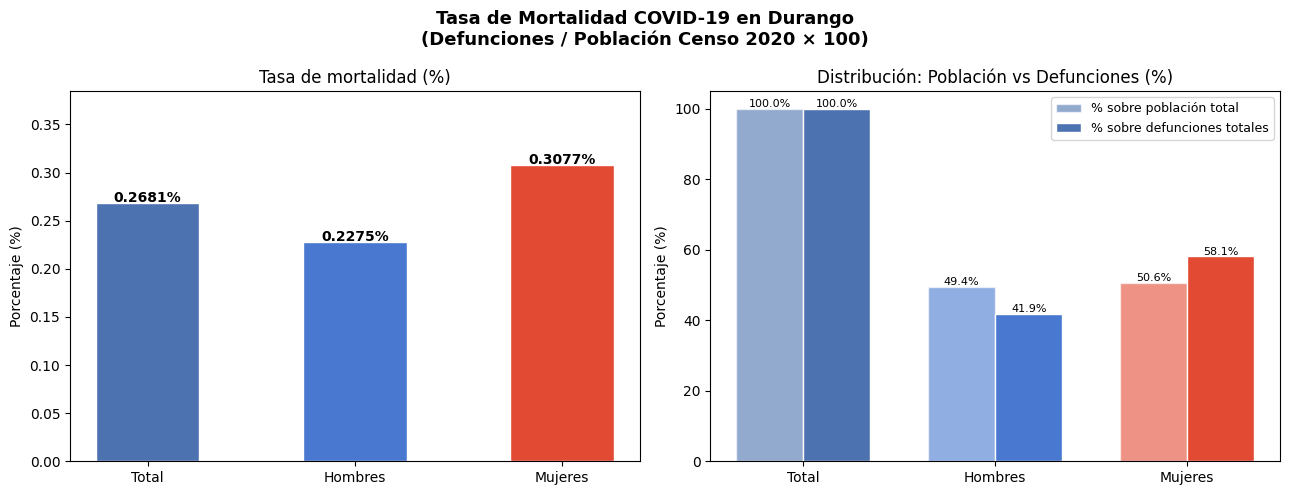

Figura guardada: tasa_mortalidad_durango.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Población INEGI Censo 2020 ────────────────────────────────
poblacion = {"Total": 1_832_650, "Hombres": 904_866, "Mujeres": 927_784}

# ── Defunciones desde durango (ENTIDAD_RES=10, post-corrección) ──
filtro_base = {"ENTIDAD_RES": 10, "FECHA_DEF": {"$nin": ["9999-99-99", None]}}
defunciones = {
    "Total"  : db["durango"].count_documents(filtro_base),
    "Hombres": db["durango"].count_documents({**filtro_base, "SEXO": 1}),
    "Mujeres": db["durango"].count_documents({**filtro_base, "SEXO": 2}),
}

# ── Tasas de mortalidad ───────────────────────────────────────
tasas = {k: round((defunciones[k] / poblacion[k]) * 100, 4) for k in poblacion}

# ── Tabla resumen ─────────────────────────────────────────────
df_tasas = pd.DataFrame({
    "Población": poblacion,
    "Defunciones": defunciones,
    "Tasa (%)": tasas,
})
print("=" * 52)
print("  TASA DE MORTALIDAD COVID-19 — Durango")
print("=" * 52)
print(df_tasas.to_string())
print("=" * 52)

# ── Gráfica ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Tasa de Mortalidad COVID-19 en Durango\n(Defunciones / Población Censo 2020 × 100)",
             fontsize=13, fontweight="bold")

grupos   = list(tasas.keys())
valores  = list(tasas.values())
colores  = ["#4C72B0", "#4878CF", "#E24A33"]

# Barras de tasa
bars = axes[0].bar(grupos, valores, color=colores, edgecolor="white", width=0.5)
axes[0].set_title("Tasa de mortalidad (%)")
axes[0].set_ylabel("Porcentaje (%)")
axes[0].set_ylim(0, max(valores) * 1.25)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f"{val:.4f}%", ha="center", fontsize=10, fontweight="bold")

# Comparativa defunciones vs población (normalizada a %)
x = np.arange(len(grupos))
w = 0.35
pob_norm = [poblacion[g] / poblacion["Total"] * 100 for g in grupos]
def_norm = [defunciones[g] / defunciones["Total"] * 100 for g in grupos]

axes[1].bar(x - w/2, pob_norm, w, label="% sobre población total", color=colores, alpha=0.6, edgecolor="white")
axes[1].bar(x + w/2, def_norm, w, label="% sobre defunciones totales", color=colores, alpha=1.0, edgecolor="white")
axes[1].set_title("Distribución: Población vs Defunciones (%)")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(grupos)
axes[1].legend(fontsize=9)
for i, (p, d) in enumerate(zip(pob_norm, def_norm)):
    axes[1].text(i - w/2, p + 0.5, f"{p:.1f}%", ha="center", fontsize=8)
    axes[1].text(i + w/2, d + 0.5, f"{d:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("tasa_mortalidad_durango.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: tasa_mortalidad_durango.png")

## 13. Eliminación de campos no requeridos para el análisis

Antes del mapeo se eliminan de la colección `durango` los campos que ya no aportan valor analítico:

| Campo | Razón de eliminación |
|---|---|
| `ID_REGISTRO` | Identificador interno de carga, sin significado epidemiológico |
| `FECHA_ACTUALIZACION` | Fecha de corte del dataset de origen, no del evento clínico |

Al eliminarlos se reduce el peso de la colección y se evita confusión al interpretar los datos. Se elimina también el índice único sobre `ID_REGISTRO` previo a su borrado.

In [ ]:
# Eliminar el índice único sobre ID_REGISTRO
durango_col.drop_index("ID_REGISTRO_1")

# Eliminar los campos de todos los documentos
res = durango_col.update_many({}, {"$unset": {"ID_REGISTRO": "", "FECHA_ACTUALIZACION": ""}})
print(f"Documentos actualizados : {res.modified_count:,}")

# Verificar que ya no existen
doc = durango_col.find_one({}, {"_id": 0})
print(f"ID_REGISTRO presente    : {'ID_REGISTRO' in doc}")
print(f"FECHA_ACTUALIZACION     : {'FECHA_ACTUALIZACION' in doc}")
print(f"Columnas restantes      : {len(doc)} campos")

## 14. Mapeo de catálogos — `durango_mapeado`

Los valores numéricos del dataset corresponden a claves definidas en el **Diccionario de Datos Abiertos** de la SSa (`240708 Catalogos.xlsx`). Se reemplazan por sus descripciones textuales para que la colección sea legible e interpretable.

**Proceso:**
1. Se cargan los catálogos desde el Excel.
2. Se carga `durango` completo a pandas.
3. Se crea la columna `MUNICIPIO` (compuesta de `ENTIDAD_RES` + `MUNICIPIO_RES`) **antes** de mapear `ENTIDAD_RES`, ya que después pierde su valor numérico.
4. Se aplican todos los catálogos.
5. Se exportan a CSV en `data/`: uno sin mapear y otro mapeado.
6. Se sube la versión mapeada a MongoDB como `durango_mapeado`.

In [33]:
import pandas as pd

EXCEL = "data/240708 Catalogos.xlsx"

def cat_from_excel(sheet, key_col, val_col):
    df = pd.read_excel(EXCEL, sheet_name=sheet)
    df = df.dropna(subset=[key_col])
    return dict(zip(df[key_col].astype(int), df[val_col]))

# Catálogos generales
cat_origen       = cat_from_excel("Catálogo ORIGEN",        "CLAVE", "DESCRIPCIÓN")
cat_sector       = cat_from_excel("Catálogo SECTOR",        "CLAVE", "DESCRIPCIÓN")
cat_sexo         = cat_from_excel("Catálogo SEXO",          "CLAVE", "DESCRIPCIÓN")
cat_tipo_pac     = cat_from_excel("Catálogo TIPO_PACIENTE", "CLAVE", "DESCRIPCIÓN")
cat_si_no        = cat_from_excel("Catálogo SI_NO",         "CLAVE", "DESCRIPCIÓN")
cat_nacionalidad = cat_from_excel("Catálogo NACIONALIDAD",  "CLAVE", "DESCRIPCIÓN")
cat_antigeno     = cat_from_excel("Catálogo RESULTADO_ANTIGENO", "CLAVE", "DESCRIPCIÓN")
cat_pcr          = cat_from_excel("Catálogo RESULTADO_PCR", "CLAVE", "DESCRIPCIÓN")
cat_pcr[97]      = "NO APLICA (CASO SIN MUESTRA)"
cat_entidades    = cat_from_excel("Catálogo de ENTIDADES",  "CLAVE_ENTIDAD", "ENTIDAD_FEDERATIVA")
cat_clasif_covid = cat_from_excel("Cat CLASIFICACION_FINAL_COVID", "CLAVE", "CLASIFICACIÓN")
cat_clasif_flu   = cat_from_excel("Cat CLASIFICACION_FINAL_FLU",   "CLAVE", "CLASIFICACIÓN")

# Catálogo municipios: clave compuesta "10_001"
muni_df = pd.read_excel(EXCEL, sheet_name="Catálogo MUNICIPIOS")
cat_municipios = {
    f"{int(r['CLAVE_ENTIDAD']):02d}_{int(r['CLAVE_MUNICIPIO']):03d}": r["MUNICIPIO"]
    for _, r in muni_df.iterrows()
}

# PAIS_ORIGEN: solo 97 → NO APLICA (resto ya son strings o numéricos sin catálogo)
cat_pais_origen = {97: "NO APLICA"}

print("Catálogos cargados:")
print(f"  SEXO        : {cat_sexo}")
print(f"  ENTIDAD 10  : {cat_entidades.get(10)}")
print(f"  Municipio   : {cat_municipios.get('10_001')}")
print(f"  SI_NO       : {cat_si_no}")
print(f"  PCR (4)     : { {k: cat_pcr[k] for k in list(cat_pcr)[:4]} }")
print(f"  COVID clasif: {len(cat_clasif_covid)} claves")
print(f"  FLU clasif  : {len(cat_clasif_flu)} claves")

Catálogos cargados:
  SEXO        : {1: 'MUJER', 2: 'HOMBRE', 99: 'NO ESPECIFICADO'}
  ENTIDAD 10  : DURANGO
  Municipio   : CANATLÁN
  SI_NO       : {1: 'SI ', 2: 'NO ', 97: 'NO APLICA', 98: 'SE IGNORA', 99: 'NO ESPECIFICADO'}
  PCR (4)     : {1: 'INFLUENZA AH1N1 PMD', 2: 'INFLUENZA A H1', 3: 'INFLUENZA A H3', 4: 'INFLUENZA B'}
  COVID clasif: 7 claves
  FLU clasif  : 5 claves


In [34]:
COLS_SI_NO = [
    "ASMA", "CARDIOVASCULAR", "DIABETES", "EPOC", "HIPERTENSION", "INMUSUPR",
    "NEUMONIA", "OBESIDAD", "RENAL_CRONICA", "TABAQUISMO", "INTUBADO", "UCI",
    "EMBARAZO", "HABLA_LENGUA_INDIG", "INDIGENA", "OTRA_COM", "OTRO_CASO",
    "TOMA_MUESTRA_LAB", "TOMA_MUESTRA_ANTIGENO", "MIGRANTE",
]

# Cargar durango completo a pandas
print("Cargando durango...")
df_raw = pd.DataFrame(list(db["durango"].find({}, {"_id": 0})))
print(f"Registros: {len(df_raw):,}  |  Columnas: {len(df_raw.columns)}")

# Guardar CSV sin mapear
csv_sin_mapear = "data/durango_sin_mapear.csv"
df_raw.to_csv(csv_sin_mapear, index=False, encoding="utf-8-sig")
print(f"CSV sin mapear guardado: {csv_sin_mapear}")

Cargando durango...
Registros: 252,991  |  Columnas: 43
CSV sin mapear guardado: data/durango_sin_mapear.csv


In [39]:
import math

df_mapped = df_raw.copy()

# Paso 1: crear MUNICIPIO — combina ENTIDAD_RES + MUNICIPIO_RES como clave "10_001"
# para obtener el nombre del municipio desde el catálogo
def make_muni_key(row):
    try:
        return f"{int(row['ENTIDAD_RES']):02d}_{int(row['MUNICIPIO_RES']):03d}"
    except (ValueError, TypeError):
        return None

df_mapped["MUNICIPIO"] = df_mapped.apply(make_muni_key, axis=1).map(cat_municipios)

# Paso 2: aplicar catálogos
df_mapped["ORIGEN"]        = df_mapped["ORIGEN"].map(cat_origen)
df_mapped["SECTOR"]        = df_mapped["SECTOR"].map(cat_sector)
df_mapped["SEXO"]          = df_mapped["SEXO"].map(cat_sexo)
df_mapped["TIPO_PACIENTE"] = df_mapped["TIPO_PACIENTE"].map(cat_tipo_pac)
df_mapped["NACIONALIDAD"]  = df_mapped["NACIONALIDAD"].map(cat_nacionalidad)
df_mapped["ENTIDAD_UM"]    = df_mapped["ENTIDAD_UM"].map(cat_entidades)
df_mapped["ENTIDAD_NAC"]   = df_mapped["ENTIDAD_NAC"].map(cat_entidades)
df_mapped["ENTIDAD_RES"]   = df_mapped["ENTIDAD_RES"].map(cat_entidades)
df_mapped["PAIS_ORIGEN"]   = df_mapped["PAIS_ORIGEN"].map(cat_pais_origen).fillna(df_mapped["PAIS_ORIGEN"])
df_mapped["RESULTADO_ANTIGENO"]        = df_mapped["RESULTADO_ANTIGENO"].map(cat_antigeno)
df_mapped["RESULTADO_PCR"]             = df_mapped["RESULTADO_PCR"].map(cat_pcr)
df_mapped["RESULTADO_PCR_COINFECCION"] = df_mapped["RESULTADO_PCR_COINFECCION"].map(cat_pcr)
df_mapped["CLASIFICACION_FINAL_COVID"] = df_mapped["CLASIFICACION_FINAL_COVID"].map(cat_clasif_covid)
df_mapped["CLASIFICACION_FINAL_FLU"]   = df_mapped["CLASIFICACION_FINAL_FLU"].map(cat_clasif_flu)

# FECHA_DEF: 9999-99-99 es el codigo oficial para paciente sin defuncion
df_mapped["FECHA_DEF"] = df_mapped["FECHA_DEF"].replace("9999-99-99", "NO FALLECIDO")

for col in COLS_SI_NO:
    if col in df_mapped.columns:
        df_mapped[col] = df_mapped[col].map(cat_si_no)

# Paso 3: eliminar MUNICIPIO_RES (reemplazado por MUNICIPIO con nombre real)
df_mapped = df_mapped.drop(columns=["MUNICIPIO_RES"])

# Verificacion: df_raw tiene codigos, df_mapped tiene descripciones
print("=== Verificacion crudo -> mapeado (muestra 1 registro) ===")
# MUNICIPIO_RES (codigo) en raw -> MUNICIPIO (nombre) en mapeado
pares = [("SEXO","SEXO"),("ORIGEN","ORIGEN"),("ENTIDAD_RES","ENTIDAD_RES"),
         ("MUNICIPIO_RES","MUNICIPIO"),("DIABETES","DIABETES"),("CLASIFICACION_FINAL_COVID","CLASIFICACION_FINAL_COVID")]
for col_raw, col_map in pares:
    crudo  = df_raw[col_raw].iloc[0]
    mapped = df_mapped[col_map].iloc[0]
    print(f"  {col_raw:<35} {str(crudo):<8} -> {mapped}")

municipio_ok = df_mapped["MUNICIPIO"].notna().sum()
print(f"Columnas finales    : {len(df_mapped.columns)}")
print(f"MUNICIPIO mapeados  : {municipio_ok:,} / {len(df_mapped):,}")


csv_mapeado = "data/durango_mapeado.csv"
df_mapped.to_csv(csv_mapeado, index=False, encoding="utf-8-sig")
print(f"CSV mapeado guardado: {csv_mapeado}")


=== Verificacion crudo -> mapeado (muestra 1 registro) ===
  SEXO                                2        -> HOMBRE
  ORIGEN                              2        -> FUERA DE USMER
  ENTIDAD_RES                         8        -> CHIHUAHUA
  MUNICIPIO_RES                       37       -> JUÁREZ
  DIABETES                            2        -> NO 
  CLASIFICACION_FINAL_COVID           7        -> NEGATIVO A SARS-COV-2
Columnas finales    : 43
MUNICIPIO mapeados  : 252,991 / 252,991
CSV mapeado guardado: data/durango_mapeado.csv


In [40]:
BATCH_SIZE = 50_000

durango_mapeado = db["durango_mapeado"]
durango_mapeado.drop()

# Convertir NaN/float nan a None explícitamente antes de insertar
def sanitize(val):
    if val is None:
        return None
    if isinstance(val, float) and math.isnan(val):
        return None
    return val

docs = [{k: sanitize(v) for k, v in row.items()} for row in df_mapped.to_dict("records")]

inserted_total = 0
for i in range(0, len(docs), BATCH_SIZE):
    lote = docs[i : i + BATCH_SIZE]
    res = durango_mapeado.insert_many(lote, ordered=False)
    inserted_total += len(res.inserted_ids)
    print(f"  Lote {i//BATCH_SIZE + 1}: {inserted_total:,} insertados")

print(f"\nTotal en durango_mapeado : {durango_mapeado.count_documents({}):,}")

# Muestra de un documento mapeado
doc_ej = durango_mapeado.find_one({"ENTIDAD_RES": "DURANGO"}, {"_id": 0})
if doc_ej:
    print("\n=== Documento mapeado de ejemplo ===")
    for k, v in doc_ej.items():
        print(f"  {k:<40}: {v}")
else:
    print("\nNo se encontró documento con ENTIDAD_RES='DURANGO'")

  Lote 1: 50,000 insertados
  Lote 2: 100,000 insertados
  Lote 3: 150,000 insertados
  Lote 4: 200,000 insertados
  Lote 5: 250,000 insertados
  Lote 6: 252,991 insertados

Total en durango_mapeado : 252,991

=== Documento mapeado de ejemplo ===
  ORIGEN                                  : FUERA DE USMER
  SECTOR                                  : SSA
  ENTIDAD_UM                              : DURANGO
  SEXO                                    : HOMBRE
  ENTIDAD_NAC                             : DURANGO
  ENTIDAD_RES                             : DURANGO
  TIPO_PACIENTE                           : AMBULATORIO
  FECHA_INGRESO                           : 2020-05-06
  FECHA_SINTOMAS                          : 2020-05-05
  FECHA_DEF                               : NO FALLECIDO
  INTUBADO                                : NO APLICA
  NEUMONIA                                : NO 
  EDAD                                    : 40
  NACIONALIDAD                            : MEXICANA
  EMBARAZO    